rho round-trip — max: 2.78e-15, mean: 2.32e-16


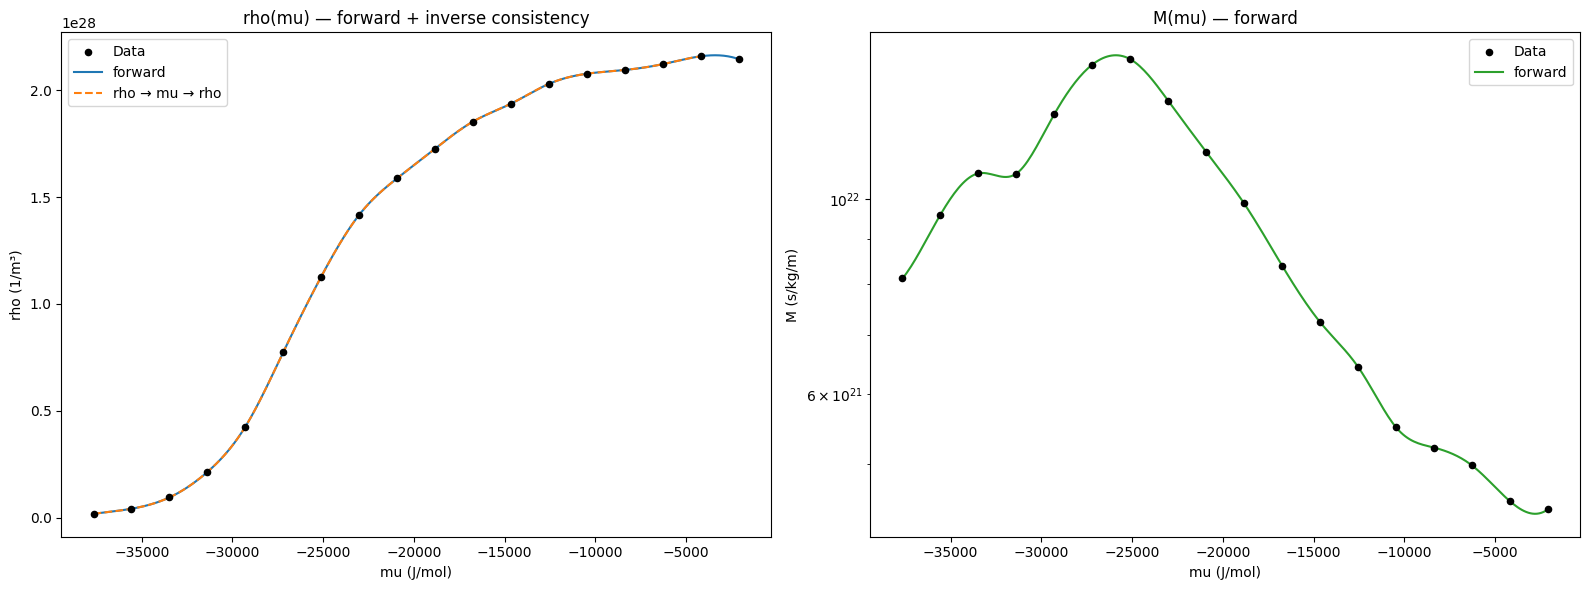

Saved 17 intervals to spline_rho_vs_mu.txt
Saved 17 intervals to spline_M_vs_mu.txt


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# ── Constants ──────────────────────────────────────────────────────────────────
volume    = 4e-9 * 4e-9 * 2e-9
area      = 4e-9 * 2e-9
m         = 40e-3
Na        = 6.022e23
kcal_to_j = 4184.0
f0_real   = 0.01
f0_SI     = f0_real * kcal_to_j * 1e10 / Na

# ── Load MD data ───────────────────────────────────────────────────────────────
md_data                 = np.loadtxt("MD/number_and_v_vs_mu.dat")
mu_real, number, v_real = md_data.T

# ── SI units ───────────────────────────────────────────────────────────────────
mu_SI  = mu_real * kcal_to_j
v_SI   = v_real * 1e-10 / 1e-15
rho_SI = number / volume
total_force = rho_SI * f0_SI * volume
total_flux  = rho_SI * v_SI * area
M_SI        = total_flux / total_force

# ── Spline fits ────────────────────────────────────────────────────────────────
cs_rho_fwd = CubicSpline(mu_SI, rho_SI)
cs_M_fwd   = CubicSpline(mu_SI, M_SI)

# ── Inversion with tracking (rho only) ────────────────────────────────────────
def invert_spline_tracked(cs, y_array, mu_min, mu_max, n_search=1000):
    mu_search = np.linspace(mu_min, mu_max, n_search)
    f_search  = cs(mu_search)
    results   = np.full(len(y_array), np.nan)
    mu_prev   = mu_min

    for i, y in enumerate(y_array):
        g            = f_search - y
        sign_changes = np.where(np.diff(np.sign(g)))[0]
        if len(sign_changes) == 0:
            continue
        candidates = []
        for idx in sign_changes:
            try:
                root = brentq(lambda mu: cs(mu) - y,
                              mu_search[idx], mu_search[idx + 1])
                candidates.append(root)
            except ValueError:
                pass
        if len(candidates) == 0:
            continue
        candidates = np.array(candidates)
        results[i] = candidates[np.argmin(np.abs(candidates - mu_prev))]
        mu_prev    = results[i]

    return results

# ── Grids ──────────────────────────────────────────────────────────────────────
mu_grid  = np.linspace(mu_SI.min(), mu_SI.max(), 300)
rho_grid = np.linspace(rho_SI.min(), rho_SI.max(), 300)

# ── Forward ────────────────────────────────────────────────────────────────────
rho_fwd = cs_rho_fwd(mu_grid)
M_fwd   = cs_M_fwd(mu_grid)

# ── rho round-trip ─────────────────────────────────────────────────────────────
mu_from_rho = invert_spline_tracked(cs_rho_fwd, rho_grid, mu_SI.min(), mu_SI.max())
rho_back    = cs_rho_fwd(mu_from_rho)

valid   = ~np.isnan(rho_back)
err_rel = np.abs(rho_back[valid] - rho_grid[valid]) / np.abs(rho_grid[valid])
print(f"rho round-trip — max: {err_rel.max():.2e}, mean: {err_rel.mean():.2e}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: rho forward + back-and-forth
axes[0].scatter(mu_SI, rho_SI, s=20, color="black", zorder=5, label="Data")
axes[0].plot(mu_grid, rho_fwd, color="tab:blue", label="forward")
axes[0].plot(mu_from_rho, rho_back, color="tab:orange",
             linestyle="--", label="rho → mu → rho")
axes[0].set_xlabel("mu (J/mol)")
axes[0].set_ylabel("rho (1/m³)")
axes[0].set_title("rho(mu) — forward + inverse consistency")
axes[0].legend()

# Right: M forward only
axes[1].scatter(mu_SI, M_SI, s=20, color="black", zorder=5, label="Data")
axes[1].plot(mu_grid, M_fwd, color="tab:green", label="forward")
axes[1].set_xlabel("mu (J/mol)")
axes[1].set_ylabel("M (s/kg/m)")
axes[1].set_title("M(mu) — forward")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Export spline coefficients for Fortran ─────────────────────────────────────
def export_spline(cs, filename):
    """
    Export CubicSpline coefficients for Fortran evaluation.
    On each interval [x_i, x_{i+1}], polynomial is:
        y = c0 + c1*(x-x_i) + c2*(x-x_i)^2 + c3*(x-x_i)^3
    cs.c has shape (4, n-1): rows = [c3, c2, c1, c0]
    """
    n = len(cs.x) - 1  # number of intervals
    data = np.column_stack([
        cs.x[:-1],   # x_left
        cs.x[1:],    # x_right
        cs.c[3],     # c0 (constant)
        cs.c[2],     # c1 (linear)
        cs.c[1],     # c2 (quadratic)
        cs.c[0],     # c3 (cubic)
    ])
    np.savetxt(filename, data,
               header=f"n_intervals={n}\nx_left  x_right  c0  c1  c2  c3",
               fmt="%.15e")
    print(f"Saved {n} intervals to {filename}")

export_spline(cs_rho_fwd, "spline_rho_vs_mu.txt")
export_spline(cs_M_fwd,   "spline_M_vs_mu.txt")